## Spotify Viral Modeling

### 1. Setup & Data Loading

#### 1.1 Setup

In [54]:
import pandas as pd 
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from joblib import load, dump

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/processed/youtube_features_cleaned.csv"

#### 1.2 Data Loading

In [55]:
df = pd.read_csv(DATA_PATH)

df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 31749 entries, 0 to 31748
Data columns (total 87 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  31749 non-null  str    
 1   track_name                31749 non-null  str    
 2   artists                   31749 non-null  str    
 3   viral                     31749 non-null  int64  
 4   virality_score            31749 non-null  float64
 5   spectral_contrast_3_std   31749 non-null  float64
 6   spectral_contrast_4_std   31749 non-null  float64
 7   spectral_bandwidth_mean   31749 non-null  float64
 8   spectral_contrast_2_std   31749 non-null  float64
 9   spectral_rolloff_std      31749 non-null  float64
 10  mfcc_1_std                31749 non-null  float64
 11  spectral_contrast_5_std   31749 non-null  float64
 12  spectral_centroid_std     31749 non-null  float64
 13  spectral_rolloff_mean     31749 non-null  float64
 14  chroma_11_std    

,viral,virality_score,spectral_contrast_3_std,spectral_contrast_4_std,spectral_bandwidth_mean,spectral_contrast_2_std,spectral_rolloff_std,mfcc_1_std,spectral_contrast_5_std,spectral_centroid_std,...,rms_mean,chroma_10_mean,chroma_8_mean,chroma_3_mean,mfcc_2_mean,view_count,like_count,comment_count,like_rate,comment_rate
count,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,...,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,3.174900e+04,3.174900e+04,3.174900e+04,31749.000000,3.174900e+04
mean,0.250024,0.322362,4.526437,3.885923,2370.329203,4.336874,1719.498708,84.805247,3.448833,818.085383,...,0.194813,0.411733,0.400114,0.392464,94.480357,4.512710e+07,3.260602e+05,1.045607e+04,0.014178,7.627092e-04
std,0.433033,0.101849,0.535697,0.629355,394.140579,0.508333,485.312186,24.403892,0.668546,239.843428,...,0.076276,0.111759,0.111302,0.108407,25.698811,2.151318e+08,1.435636e+06,5.893047e+04,0.022707,2.586327e-03
min,0.000000,0.013653,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-10.503011,1.800000e+01,1.000000e+00,1.000000e+00,0.000308,2.945353e-08
25%,0.000000,0.248926,4.175226,3.489817,2192.392013,3.990232,1392.148030,68.331734,3.029212,658.403070,...,0.139395,0.333173,0.320684,0.317504,77.324661,6.420200e+04,7.960000e+02,2.200000e+01,0.007277,1.507020e-04
50%,0.000000,0.321212,4.495128,3.873782,2442.923351,4.289732,1725.216280,83.703705,3.446319,815.339334,...,0.199104,0.405968,0.394671,0.386260,91.213409,6.934300e+05,8.234000e+03,2.140000e+02,0.011322,3.035430e-04
75%,1.000000,0.395975,4.842621,4.267083,2629.057347,4.641510,2056.553823,100.107620,3.853372,971.909737,...,0.249369,0.484760,0.471934,0.460236,108.321098,8.214287e+06,8.235000e+04,2.000000e+03,0.017228,6.567440e-04
max,1.000000,0.600731,8.599688,14.916294,3508.484386,7.563166,3719.327015,245.159164,8.153509,2505.117807,...,0.618765,0.951920,0.899359,0.897716,240.255096,6.965732e+09,4.638637e+07,2.400000e+06,3.553191,1.578947e-01


### 2. Feature & Target Preparation

#### 2.1 Create Features

In [56]:
# Calculate engagement rates
df['like_rate'] = df['like_count'] / (df['view_count'] + 1)
df['comment_rate'] = df['comment_count'] / (df['view_count'] + 1)
df['total_engagement_rate'] = df['like_rate'] + df['comment_rate']

# Log transform views (highly skewed)
df['log_views'] = np.log1p(df['view_count'])

print("✓ Basic features created (engagement rates, log transform)")
print("\nNote: Scaling and viral label creation will be done AFTER train-test split to prevent data leakage.")

✓ Basic features created (engagement rates, log transform)

Note: Scaling and viral label creation will be done AFTER train-test split to prevent data leakage.


In [57]:
# Create temporary feature matrix for splitting (before scaling and viral label)
# Drop only non-feature columns
X_temp = df.drop(['track_id', 'track_name', 'artists', 'like_rate', 'comment_rate', 'total_engagement_rate', 'log_views'], axis=1)

print("Temporary feature matrix created for splitting")

Temporary feature matrix created for splitting


#### 2.2 Create Target

#### 2.3 Train/Test Split

In [58]:
# Split data BEFORE scaling and creating target
# This prevents data leakage - we fit scalers and compute thresholds only on training data
X_train_idx, X_test_idx = train_test_split(
    range(len(X_temp)), 
    test_size=0.2, 
    random_state=42
)

print(f"✓ Train-test split completed")
print(f"  Train indices: {len(X_train_idx)}, Test indices: {len(X_test_idx)}")

✓ Train-test split completed
  Train indices: 25399, Test indices: 6350


In [59]:
print(f"Training set size: {len(X_train_idx)}, Test set size: {len(X_test_idx)}")

Training set size: 25399, Test set size: 6350


In [60]:
# ============================================================================
# SCALING AND VIRAL LABEL CREATION (After Split to Prevent Data Leakage)
# ============================================================================

# Fit scalers ONLY on training data indices
scaler_views = MinMaxScaler()
scaler_engagement = MinMaxScaler()

train_log_views = df.loc[X_train_idx, 'log_views'].values.reshape(-1, 1)
train_engagement = df.loc[X_train_idx, 'total_engagement_rate'].values.reshape(-1, 1)

scaler_views.fit(train_log_views)
scaler_engagement.fit(train_engagement)

# Transform all data using train-fitted scalers
df['views_norm'] = scaler_views.transform(df['log_views'].values.reshape(-1, 1)).flatten()
df['engagement_norm'] = scaler_engagement.transform(df['total_engagement_rate'].values.reshape(-1, 1)).flatten()

# Create composite virality score
df['virality_score'] = 0.6 * df['views_norm'] + 0.4 * df['engagement_norm']

# Calculate viral threshold ONLY using training data
train_virality_scores = df.loc[X_train_idx, 'virality_score']
viral_threshold = train_virality_scores.quantile(0.75)

# Apply threshold to all data (but based on train distribution)
df['viral'] = (df['virality_score'] >= viral_threshold).astype(int)

print(f"✓ Scaling and viral label creation completed (post-split)")
print(f"\nVirality threshold (from training data): {viral_threshold:.3f}")
print(f"\nViral distribution (full dataset):")
print(df['viral'].value_counts())
print(f"\nViral songs: {df['viral'].sum():,} ({df['viral'].sum()/len(df)*100:.1f}%)")

print(f"\nTraining set viral distribution:")
print(df.loc[X_train_idx, 'viral'].value_counts())
print(f"\nTest set viral distribution:")
print(df.loc[X_test_idx, 'viral'].value_counts())

✓ Scaling and viral label creation completed (post-split)

Virality threshold (from training data): 0.410

Viral distribution (full dataset):
viral
0    23786
1     7963
Name: count, dtype: int64

Viral songs: 7,963 (25.1%)

Training set viral distribution:
viral
0    19049
1     6350
Name: count, dtype: int64

Test set viral distribution:
viral
0    4737
1    1613
Name: count, dtype: int64


In [61]:
# ============================================================================
# CREATE FINAL FEATURE MATRIX AND TARGET (NO DATA LEAKAGE)
# ============================================================================

# Drop ALL engagement-related columns to prevent data leakage
# The target 'viral' is defined based on these metrics, so they can't be features
X = df.drop(['track_id', 'track_name', 'artists', 'viral', 'virality_score', 
              'like_count', 'comment_count', 'view_count',  # Raw engagement metrics
              'like_rate', 'comment_rate', 'total_engagement_rate',  # Derived engagement rates
              'views_norm', 'engagement_norm',  # Normalized engagement (part of target definition)
              'log_views'], axis=1)  # Log-transformed views

# Create target
y = df['viral']

# Apply pre-computed train/test split indices
X_train, X_test = X.iloc[X_train_idx], X.iloc[X_test_idx]
y_train, y_test = y.iloc[X_train_idx], y.iloc[X_test_idx]

print("✓ Final feature matrix and target created")
print(f"\nX shape: {X.shape}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

✓ Final feature matrix and target created

X shape: (31749, 77)
X_train shape: (25399, 77), X_test shape: (6350, 77)

Class distribution in training set:
viral
0    19049
1     6350
Name: count, dtype: int64

Class distribution in test set:
viral
0    4737
1    1613
Name: count, dtype: int64


In [62]:
# ============================================================================
# DEBUG: Check what columns are actually in X_train
# ============================================================================

print("Features in X_train:")
print(X_train.columns.tolist())
print(f"\nTotal features: {X_train.shape[1]}")

# Check if any engagement metrics snuck in
engagement_cols = ['like_count', 'comment_count', 'view_count', 'views_norm', 'engagement_norm', 'like_rate', 'comment_rate']
leaked = [col for col in engagement_cols if col in X_train.columns]
if leaked:
    print(f"\n⚠️  DATA LEAKAGE DETECTED: {leaked}")
else:
    print("\n✅ No engagement metrics in features (clean!)")

Features in X_train:
['spectral_contrast_3_std', 'spectral_contrast_4_std', 'spectral_bandwidth_mean', 'spectral_contrast_2_std', 'spectral_rolloff_std', 'mfcc_1_std', 'spectral_contrast_5_std', 'spectral_centroid_std', 'spectral_rolloff_mean', 'chroma_11_std', 'chroma_2_std', 'mfcc_6_std', 'chroma_4_std', 'mfcc_10_std', 'chroma_9_std', 'spectral_contrast_7_std', 'spectral_centroid_mean', 'chroma_12_std', 'mfcc_8_std', 'mfcc_9_std', 'chroma_7_std', 'spectral_bandwidth_std', 'mfcc_7_std', 'chroma_1_std', 'mfcc_10_mean', 'mfcc_13_std', 'spectral_contrast_6_std', 'onset_strength_mean', 'chroma_5_std', 'zcr_std', 'chroma_6_std', 'mfcc_11_std', 'zcr_mean', 'mfcc_12_std', 'onset_strength_std', 'mfcc_7_mean', 'chroma_8_std', 'chroma_10_std', 'mfcc_5_std', 'mfcc_1_mean', 'mfcc_4_std', 'mfcc_5_mean', 'chroma_3_std', 'mfcc_9_mean', 'spectral_contrast_1_std', 'mfcc_12_mean', 'spectral_contrast_3_mean', 'spectral_contrast_5_mean', 'spectral_contrast_4_mean', 'mfcc_3_std', 'mfcc_11_mean', 'tonnetz_

In [63]:


df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 31749 entries, 0 to 31748
Data columns (total 91 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  31749 non-null  str    
 1   track_name                31749 non-null  str    
 2   artists                   31749 non-null  str    
 3   viral                     31749 non-null  int64  
 4   virality_score            31749 non-null  float64
 5   spectral_contrast_3_std   31749 non-null  float64
 6   spectral_contrast_4_std   31749 non-null  float64
 7   spectral_bandwidth_mean   31749 non-null  float64
 8   spectral_contrast_2_std   31749 non-null  float64
 9   spectral_rolloff_std      31749 non-null  float64
 10  mfcc_1_std                31749 non-null  float64
 11  spectral_contrast_5_std   31749 non-null  float64
 12  spectral_centroid_std     31749 non-null  float64
 13  spectral_rolloff_mean     31749 non-null  float64
 14  chroma_11_std    

,viral,virality_score,spectral_contrast_3_std,spectral_contrast_4_std,spectral_bandwidth_mean,spectral_contrast_2_std,spectral_rolloff_std,mfcc_1_std,spectral_contrast_5_std,spectral_centroid_std,...,mfcc_2_mean,view_count,like_count,comment_count,like_rate,comment_rate,total_engagement_rate,log_views,views_norm,engagement_norm
count,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,31749.000000,...,31749.000000,3.174900e+04,3.174900e+04,3.174900e+04,31749.000000,3.174900e+04,31749.000000,31749.000000,31749.000000,31749.000000
mean,0.250811,0.339815,4.526437,3.885923,2370.329203,4.336874,1719.498708,84.805247,3.448833,818.085383,...,94.480357,4.512710e+07,3.260602e+05,1.045607e+04,0.014178,7.627092e-04,0.014941,13.486018,0.532193,0.051249
std,0.433487,0.100430,0.535697,0.629355,394.140579,0.508333,485.312186,24.403892,0.668546,239.843428,...,25.698811,2.151318e+08,1.435636e+06,5.893047e+04,0.022707,2.586327e-03,0.023586,3.366925,0.171609,0.083438
min,0.000000,0.075345,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-10.503011,1.800000e+01,1.000000e+00,1.000000e+00,0.000308,2.945353e-08,0.000454,2.944439,-0.005101,0.000000
25%,0.000000,0.267327,4.175226,3.489817,2192.392013,3.990232,1392.148030,68.331734,3.029212,658.403070,...,77.324661,6.420200e+04,7.960000e+02,2.200000e+01,0.007277,1.507019e-04,0.007518,11.069805,0.409041,0.024991
50%,0.000000,0.338571,4.495128,3.873782,2442.923351,4.289732,1725.216280,83.703705,3.446319,815.339334,...,91.213409,6.934300e+05,8.234000e+03,2.140000e+02,0.011322,3.035429e-04,0.011674,13.449407,0.530327,0.039691
75%,1.000000,0.410256,4.842621,4.267083,2629.057347,4.641510,2056.553823,100.107620,3.853372,971.909737,...,108.321098,8.214287e+06,8.235000e+04,2.000000e+03,0.017228,6.567439e-04,0.017936,15.921386,0.656322,0.061844
max,1.000000,5.081990,8.599688,14.916294,3508.484386,7.563166,3719.327015,245.159164,8.153509,2505.117807,...,240.255096,6.965732e+09,4.638637e+07,2.400000e+06,3.553191,1.578947e-01,3.574468,22.664268,1.000000,12.643381


### 3. Modeling 

#### 3.1 Baseline Model - Decision Tree Classifier

In [92]:
from sklearn.tree import DecisionTreeClassifier

In [93]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=15,  # Prevent overfitting
    min_samples_split=20,
    min_samples_leaf=10
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Training Accuracy: 0.8322
Testing Accuracy: 0.7383
Precision: 0.4818
Recall: 0.4017
F1 Score: 0.4381


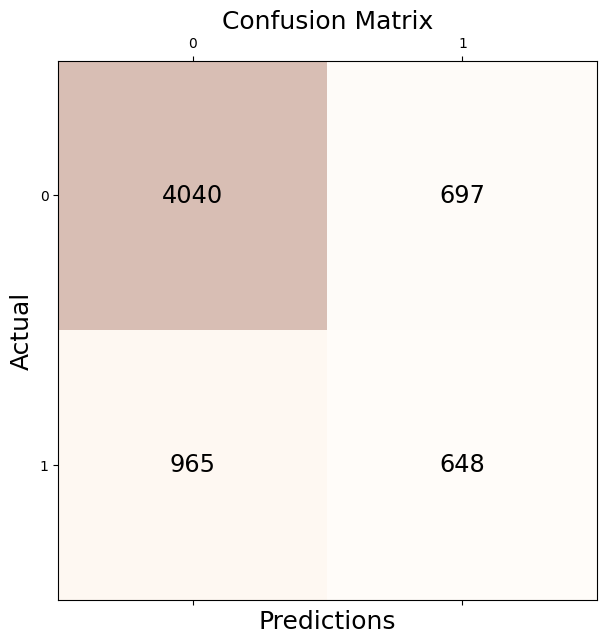

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      4737
           1       0.48      0.40      0.44      1613

    accuracy                           0.74      6350
   macro avg       0.64      0.63      0.63      6350
weighted avg       0.72      0.74      0.73      6350



In [94]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")

conf_matrix = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred))

In [95]:
print("Accuracy: ", (conf_matrix[0,0]+conf_matrix[1,1])/(conf_matrix[0,0]+conf_matrix[1,1]+conf_matrix[0,1]+conf_matrix[1,0]) )
print("Precision of non-viral: ", (conf_matrix[0,0])/(conf_matrix[0,0]+conf_matrix[0,1]) )
print("Recall of non-viral: ", (conf_matrix[0,0])/(conf_matrix[0,0]+conf_matrix[1,0]) )

Accuracy:  0.7382677165354331
Precision of non-viral:  0.852860460206882
Recall of non-viral:  0.8071928071928072


In [96]:
# ============================================================================
# DECISION TREE WITH REGULARIZATION (No Overfitting)
# ============================================================================

print("Decision Tree with depth constraints to prevent overfitting...\n")

dt_regularized = DecisionTreeClassifier(
    random_state=42,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10
)
dt_regularized.fit(X_train, y_train)

y_train_pred_dt_reg = dt_regularized.predict(X_train)
y_test_pred_dt_reg = dt_regularized.predict(X_test)

print(f"✅ Regularized Decision Tree:")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_dt_reg):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_dt_reg):.4f}")
print(f"Gap: {accuracy_score(y_train, y_train_pred_dt_reg) - accuracy_score(y_test, y_test_pred_dt_reg):.4f}")
print(f"\nPrecision: {precision_score(y_test, y_test_pred_dt_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_dt_reg):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_dt_reg):.4f}")

conf_matrix_dt_reg = confusion_matrix(y_test, y_test_pred_dt_reg)
print("\n" + classification_report(y_test, y_test_pred_dt_reg))

print("\n" + "="*70)
print("COMPARISON: Unconstrained vs Regularized")
print("="*70)
print(f"Unregularized: Train=1.0000, Test=0.7603, Gap=0.2397")
print(f"Regularized:   Train={accuracy_score(y_train, y_train_pred_dt_reg):.4f}, "
      f"Test={accuracy_score(y_test, y_test_pred_dt_reg):.4f}, "
      f"Gap={accuracy_score(y_train, y_train_pred_dt_reg) - accuracy_score(y_test, y_test_pred_dt_reg):.4f}")
print("\n✅ Much better generalization!")


Decision Tree with depth constraints to prevent overfitting...

✅ Regularized Decision Tree:
Training Accuracy: 0.8322
Testing Accuracy: 0.7383
Gap: 0.0939

Precision: 0.4818
Recall: 0.4017
F1 Score: 0.4381

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      4737
           1       0.48      0.40      0.44      1613

    accuracy                           0.74      6350
   macro avg       0.64      0.63      0.63      6350
weighted avg       0.72      0.74      0.73      6350


COMPARISON: Unconstrained vs Regularized
Unregularized: Train=1.0000, Test=0.7603, Gap=0.2397
Regularized:   Train=0.8322, Test=0.7383, Gap=0.0939

✅ Much better generalization!


#### 3.4 Baseline Model - LightGBM Classifier

In [97]:
import lightgbm as lgb

In [98]:
lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,  # Handle imbalanced data
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [99]:
lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Training Accuracy: 0.9915
Testing Accuracy: 0.8162
Precision: 0.6479
Recall: 0.6057
F1 Score: 0.6261


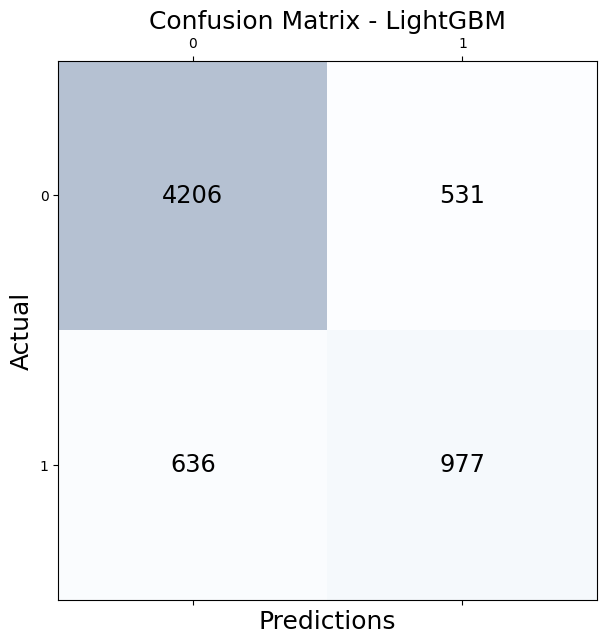

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4737
           1       0.65      0.61      0.63      1613

    accuracy                           0.82      6350
   macro avg       0.76      0.75      0.75      6350
weighted avg       0.81      0.82      0.81      6350



In [100]:
y_train_pred_lgbm = lgbm.predict(X_train)
y_test_pred_lgbm = lgbm.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_lgbm):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_lgbm):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_lgbm):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_lgbm):.4f}")

conf_matrix_lgbm = confusion_matrix(y_test, y_test_pred_lgbm)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_lgbm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix_lgbm.shape[0]):
    for j in range(conf_matrix_lgbm.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_lgbm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix - LightGBM', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_lgbm))

In [101]:
print("Accuracy: ", (conf_matrix_lgbm[0,0]+conf_matrix_lgbm[1,1])/(conf_matrix_lgbm[0,0]+conf_matrix_lgbm[1,1]+conf_matrix_lgbm[0,1]+conf_matrix_lgbm[1,0]) )
print("Precision of non-viral: ", (conf_matrix_lgbm[0,0])/(conf_matrix_lgbm[0,0]+conf_matrix_lgbm[0,1]) )
print("Recall of non-viral: ", (conf_matrix_lgbm[0,0])/(conf_matrix_lgbm[0,0]+conf_matrix_lgbm[1,0]) )

Accuracy:  0.8162204724409449
Precision of non-viral:  0.8879037365421153
Recall of non-viral:  0.8686493184634448


#### 4.5 RandomizedSearchCV on LightGBM Classifier

In [103]:
from scipy.stats import uniform, randint, loguniform

In [104]:
# Define hyperparameter distribution for RandomizedSearchCV
lgbm_param_dist = {
    'n_estimators': randint(100, 2000),
    'learning_rate': loguniform(0.001, 0.3),
    'num_leaves': randint(20, 150),
    'max_depth': randint(3, 20),
    'min_child_samples': randint(5, 50),
    'min_child_weight': loguniform(0.001, 1),
    'subsample': uniform(0.5, 0.5),  # Range: 0.5 to 1.0
    'colsample_bytree': uniform(0.5, 0.5),  # Range: 0.5 to 1.0
    'reg_alpha': loguniform(0.001, 10),
    'reg_lambda': loguniform(0.001, 10),
}

print("LightGBM Parameter Distribution:")
for param, dist in lgbm_param_dist.items():
    print(f"  {param}: {dist}")


LightGBM Parameter Distribution:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001571371C9B0>
  learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000015713C9EB60>
  num_leaves: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001571371CF50>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000015719275E10>
  min_child_samples: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000015719276B30>
  min_child_weight: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000015713B82E10>
  subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000015713A562D0>
  colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000157192E7CD0>
  reg_alpha: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001571B804310>
  reg_lambda: <scipy.stats._distn_infrastructure.rv_co

In [105]:
# Perform RandomizedSearchCV for LightGBM
print("Starting LightGBM Hyperparameter Tuning...")
print("=" * 70)

lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_dist,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',  # Use F1 score as optimization metric
    n_jobs=-1,  # Use all cores
    verbose=1,
    random_state=42
)

# Fit the random search
lgbm_random_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("LightGBM Hyperparameter Tuning Complete")
print("=" * 70)
print(f"\nBest Parameters: {lgbm_random_search.best_params_}")
print(f"Best Cross-Val F1 Score: {lgbm_random_search.best_score_:.4f}")


Starting LightGBM Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

LightGBM Hyperparameter Tuning Complete

Best Parameters: {'colsample_bytree': np.float64(0.8248164495236073), 'learning_rate': np.float64(0.1269490221959903), 'max_depth': 19, 'min_child_samples': 37, 'min_child_weight': np.float64(0.042424886748968306), 'n_estimators': 1054, 'num_leaves': 134, 'reg_alpha': np.float64(0.3510188772233666), 'reg_lambda': np.float64(0.010042625655461325), 'subsample': np.float64(0.7949354237802719)}
Best Cross-Val F1 Score: 0.8242


In [106]:
# Extract best parameters and create tuned model
best_params_lgbm = lgbm_random_search.best_params_
best_params_lgbm['is_unbalance'] = True  # Keep this parameter
best_params_lgbm['random_state'] = 42
best_params_lgbm['n_jobs'] = -1
best_params_lgbm['verbose'] = -1

lgbm_tuned = lgb.LGBMClassifier(**best_params_lgbm)
lgbm_tuned.fit(X_train, y_train)

print("LightGBM tuned model trained successfully!")


LightGBM tuned model trained successfully!


Training Accuracy: 1.0000
Testing Accuracy: 0.8454
Precision: 0.8072
Recall: 0.5139
F1 Score: 0.6280


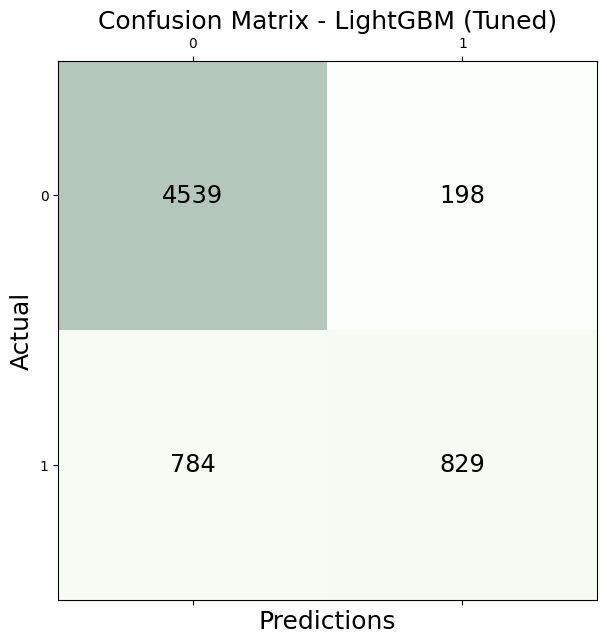

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4737
           1       0.81      0.51      0.63      1613

    accuracy                           0.85      6350
   macro avg       0.83      0.74      0.77      6350
weighted avg       0.84      0.85      0.83      6350



In [107]:
# Evaluate tuned LightGBM model
y_train_pred_lgbm_tuned = lgbm_tuned.predict(X_train)
y_test_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

# Model Evaluations
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_lgbm_tuned):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_lgbm_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_lgbm_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_lgbm_tuned):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_lgbm_tuned):.4f}")

conf_matrix_lgbm_tuned = confusion_matrix(y_test, y_test_pred_lgbm_tuned)

fig, ax = plt.subplots(figsize=(10, 7))
ax.matshow(conf_matrix_lgbm_tuned, cmap=plt.cm.Greens, alpha=0.3)
for i in range(conf_matrix_lgbm_tuned.shape[0]):
    for j in range(conf_matrix_lgbm_tuned.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix_lgbm_tuned[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix - LightGBM (Tuned)', fontsize=18)
plt.show()

print(classification_report(y_test, y_test_pred_lgbm_tuned))


In [108]:
print("Accuracy: ", (conf_matrix_lgbm_tuned[0,0]+conf_matrix_lgbm_tuned[1,1])/(conf_matrix_lgbm_tuned[0,0]+conf_matrix_lgbm_tuned[1,1]+conf_matrix_lgbm_tuned[0,1]+conf_matrix_lgbm_tuned[1,0]) )
print("Precision of non-viral: ", (conf_matrix_lgbm_tuned[0,0])/(conf_matrix_lgbm_tuned[0,0]+conf_matrix_lgbm_tuned[0,1]) )
print("Recall of non-viral: ", (conf_matrix_lgbm_tuned[0,0])/(conf_matrix_lgbm_tuned[0,0]+conf_matrix_lgbm_tuned[1,0]) )


Accuracy:  0.8453543307086614
Precision of non-viral:  0.9582013932868905
Recall of non-viral:  0.8527146346045463


In [111]:
from joblib import dump
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the tuned LightGBM model
model_path = 'models/lgbm_randomized.joblib'
dump(lgbm_tuned, model_path)

print(f"✓ LightGBM tuned model saved to: {model_path}")
print(f"Model file size: {os.path.getsize(model_path) / (1024*1024):.2f} MB")


✓ LightGBM tuned model saved to: models/lgbm_randomized.joblib
Model file size: 8.90 MB


In [113]:
import joblib

# Load the LGBM model
model = joblib.load('models/lgbm_randomized.joblib')

# Now you can use it for predictions
predictions = model.predict(X_test)

In [115]:
# Feature Importance Analysis
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))
print(f"\nTotal features: {len(feature_importance)}")


Top 10 Most Important Features:
                     feature  importance
5                 mfcc_1_std        1752
15   spectral_contrast_7_std        1695
58                   rms_std        1639
35               mfcc_7_mean        1628
72                  rms_mean        1617
55  spectral_contrast_1_mean        1604
24              mfcc_10_mean        1556
71  spectral_contrast_7_mean        1553
43               mfcc_9_mean        1530
61               mfcc_4_mean        1514

Total features: 77


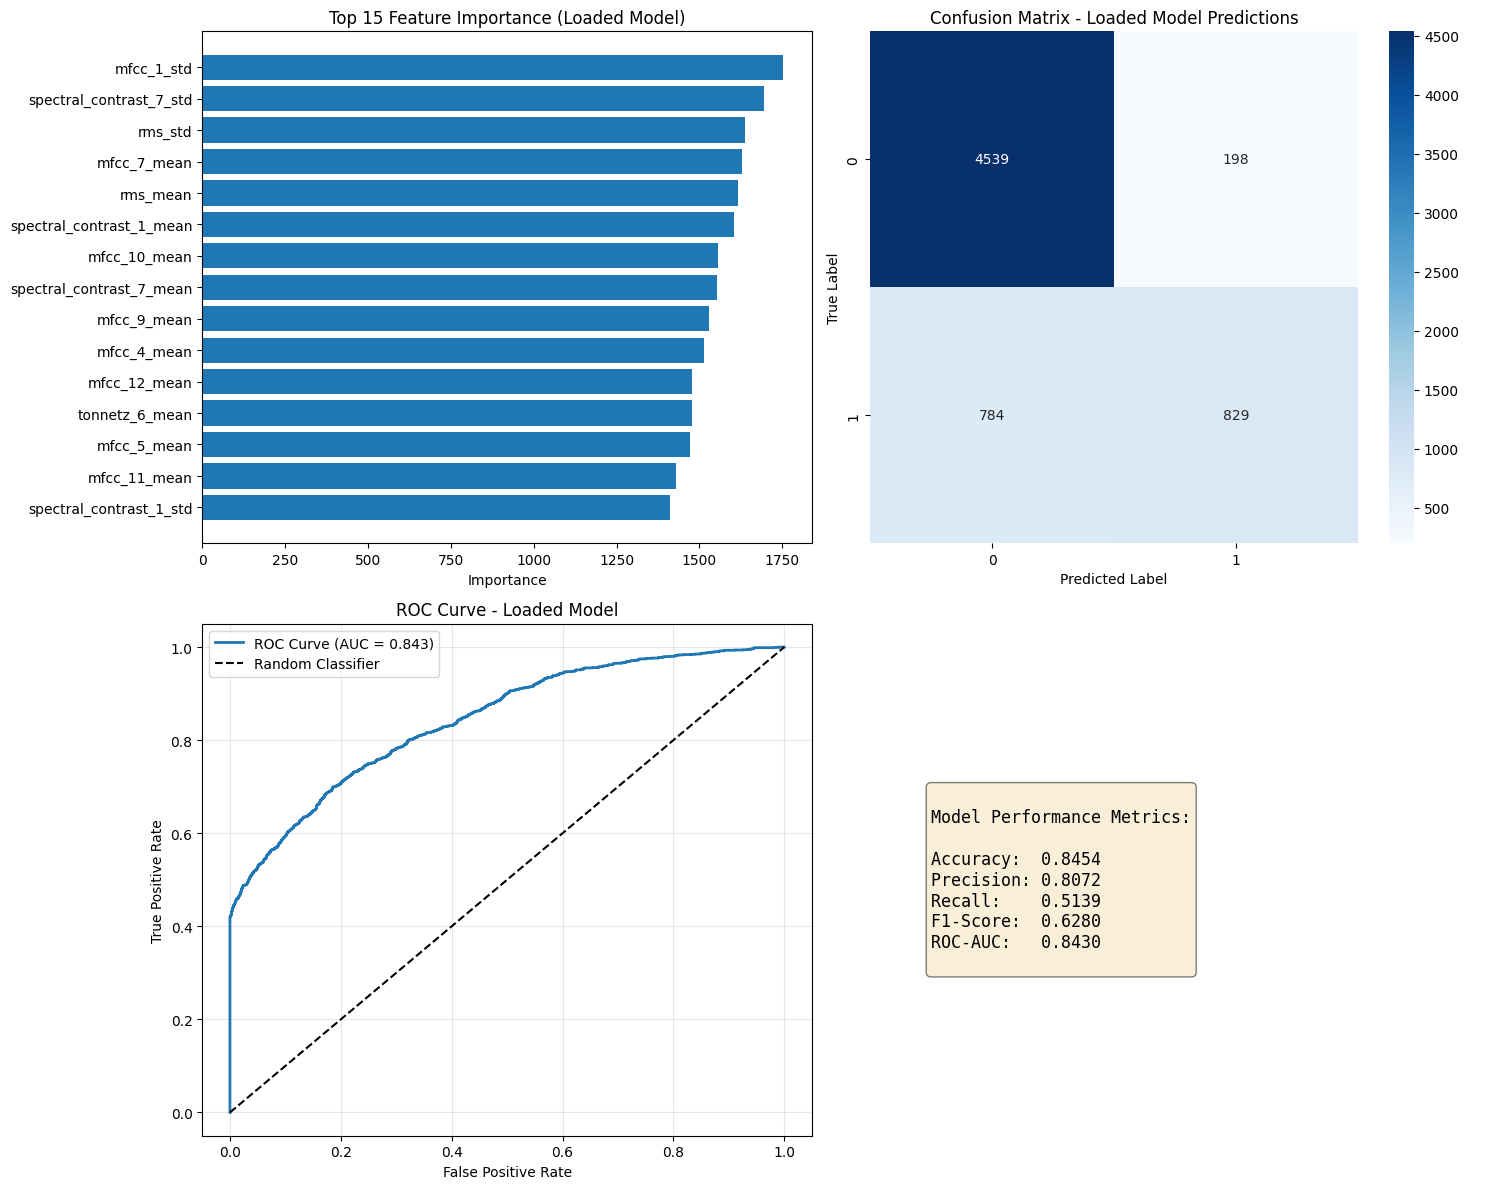


Detailed Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.85      0.96      0.90      4737
       Viral       0.81      0.51      0.63      1613

    accuracy                           0.85      6350
   macro avg       0.83      0.74      0.77      6350
weighted avg       0.84      0.85      0.83      6350



In [117]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Feature Importance Plot
top_n = 15
top_features = feature_importance.head(top_n)
axes[0, 0].barh(range(len(top_features)), top_features['importance'])
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['feature'])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title(f'Top {top_n} Feature Importance (Loaded Model)')
axes[0, 0].invert_yaxis()

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix - Loaded Model Predictions')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
axes[1, 0].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve - Loaded Model')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

metrics_text = f"""
Model Performance Metrics:

Accuracy:  {accuracy:.4f}
Precision: {precision:.4f}
Recall:    {recall:.4f}
F1-Score:  {f1:.4f}
ROC-AUC:   {roc_auc:.4f}
"""

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions, target_names=['Not Viral', 'Viral']))
